## 0. 导入库

In [1]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import multiprocessing
from datetime import datetime as datetime
import spectral as sp

## 1. 读取光谱数据

In [2]:
import spectral as sp
import numpy as np

# hdrpath = 'E:/WuJiangying/DEM/WZD_mask_L9.hdr'
# datpath = 'E:/WuJiangying/DEM/WZD_mask_L9.dat'
hdrpath = 'data/WZD_mask_L9.hdr'
datpath = 'data/WZD_mask_L9.dat'
head = sp.envi.open(hdrpath, datpath)
print(head)

data = head.load()
print(f'data shape: {data.shape}')
print(f'data type: {data.dtype}')
print(f'data max: {np.max(data)}')
print(f'data min: {np.min(data)}')

	Data Source:   '.\data/WZD_mask_L9.dat'
	# Rows:            101
	# Samples:         100
	# Bands:             7
	Interleave:        BSQ
	Quantization:  16 bits
	Data format:     int16
data shape: (101, 100, 7)
data type: float32
data max: 0.10589999705553055
data min: 0.0


## 2. 读取深度数据

In [3]:
# depthhdrpath = 'E:/WuJiangying/DEM/ture_dem_9_.txt'
# depthdatpath = 'E:/WuJiangying/DEM/ture_dem_9'
depthhdrpath = 'data/ture_dem_9_.hdr'
depthdatpath = 'data/ture_dem_9'
depthhead = sp.envi.open(depthhdrpath, depthdatpath)
print(depthhead)

depthdata = depthhead.load()
print(f'depthdata shape: {depthdata.shape}')
print(f'depthdata type: {depthdata.dtype}')
print(f'depthdata max: {np.max(depthdata)}')
print(f'depthdata min: {np.min(depthdata)}')

	Data Source:   '.\data/ture_dem_9'
	# Rows:            100
	# Samples:          99
	# Bands:             1
	Interleave:        BSQ
	Quantization:  64 bits
	Data format:   float64
depthdata shape: (100, 99, 1)
depthdata type: float32
depthdata max: -0.18000000715255737
depthdata min: -21.75


## 3. 数据预处理

- reshape
- normalization
- 数据随机切分

In [4]:
# newdata delete first row and last column
newdata = data[1:, :-1]
print(f'newdata shape: {newdata.shape}')

newdata shape: (100, 99, 7)


In [5]:
# reshaope
# newdata 100*99*7 -> 9900*7
# depthdata 100*99*1 -> 9900*1
newdata_ = newdata.reshape(-1, newdata.shape[-1])
depthdata_ = depthdata.reshape(-1, 1)
print(f'newdata_ shape: {newdata_.shape}')
print(f'depthdata_ shape: {depthdata_.shape}')

newdata_ shape: (9900, 7)
depthdata_ shape: (9900, 1)


归一化

In [6]:
# normalize the newdata to [0, 1], depthdata to [0, 1]
datamax, datamin = np.max(newdata_), np.min(newdata_)
depthmax, depthmin = np.max(depthdata_), np.min(depthdata_)
print(f'datamax: {datamax}, datamin: {datamin}')
print(f'depthmax: {depthmax}, depthmin: {depthmin}')

newdata_ = (newdata_ - datamin) / (datamax - datamin)
depthdata_ = (depthdata_ - depthmin) / (depthmax - depthmin)
print(f'newdata_ max: {np.max(newdata_)}, newdata_ min: {np.min(newdata_)}')
print(f'depthdata_ max: {np.max(depthdata_)}, depthdata_ min: {np.min(depthdata_)}')
print(f'newdata_ shape: {newdata_.shape}')
print(f'depthdata_ shape: {depthdata_.shape}')

datamax: 0.10589999705553055, datamin: 0.0
depthmax: -0.18000000715255737, depthmin: -21.75
newdata_ max: 1.0, newdata_ min: 0.0
depthdata_ max: 1.0, depthdata_ min: 0.0
newdata_ shape: (9900, 7)
depthdata_ shape: (9900, 1)


随机切分

In [7]:
import torch
import numpy as np
import random

def set_random_seed(seed):
    """Set random seeds."""
    random.seed(seed)  # Python 内置随机库
    np.random.seed(seed)  # NumPy 随机库
    torch.manual_seed(seed)  # PyTorch 随机库
    torch.cuda.manual_seed(seed)  # 当前 CUDA 设备
    torch.cuda.manual_seed_all(seed)  # 所有 CUDA 设备
    torch.backends.cudnn.deterministic = True  # 确定性卷积操作
    
    # torch.backends.cudnn.benchmark = False  # 禁止自动优化

In [8]:
setseed = 3407
set_random_seed(setseed)
train_num, test_num = 900, 100

# TRAIN
# selcet train_num rows in train_num rows
train_index = random.sample(range(newdata_.shape[0]), train_num)
train_samples = newdata_[train_index]
train_depths = depthdata_[train_index]
print(f'train_samples shape: {train_samples.shape}')
print(f'train_depths shape: {train_depths.shape}')

# TEST
# select test_num rows in rest rows
test_index = list(set(range(newdata_.shape[0])) - set(train_index))
test_index = random.sample(test_index, test_num)
test_samples = newdata_[test_index]
test_depths = depthdata_[test_index]
print(f'test_samples shape: {test_samples.shape}')
print(f'test_depths shape: {test_depths.shape}')


train_samples shape: (900, 7)
train_depths shape: (900, 1)
test_samples shape: (100, 7)
test_depths shape: (100, 1)


## 4. 构建模型 以及 训练

In [9]:
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from datetime import datetime as datetime
import joblib  # 用于保存模型
import os  # 用于创建文件夹


X_train = train_samples
y_train = train_depths  # 连续值标签
X_test = test_samples
y_test = test_depths  # 连续值标签


# KNN 回归模型
n_neighbors = 5  # 最近邻的数量
knn = KNeighborsRegressor(n_neighbors=n_neighbors, weights='uniform')  # weights='distance' 使用加权距离

# 训练模型
a = datetime.now()
print(f'开始训练时间：{a}')
knn.fit(X_train, y_train.ravel())
b = datetime.now()
print(f'结束训练时间：{b}')
print(f'训练用时：{b-a}')
print()

# 保存训练好的模型到指定路径
if not os.path.exists('./ckpt'):
    os.makedirs('./ckpt')
model_path = './ckpt/knn.pkl'
joblib.dump(knn, model_path)
print(f'Model saved to {model_path}')

开始训练时间：2025-01-01 17:47:55.066130
结束训练时间：2025-01-01 17:47:55.067634
训练用时：0:00:00.001504

Model saved to ./ckpt/knn.pkl


## 5. 预测 及 结果展示

- 图1
    - 画出深度图
    - 画出预测的深度图
- 图2
    - 画出 实际-预测 的深度图
    - 拟合直线
    - 计算 NMSE，R 展示到图片上

开始测试时间：2025-01-01 17:47:55.079666
结束测试时间：2025-01-01 17:47:55.079666
测试用时：0:00:00

Mean Squared Error: 0.011097


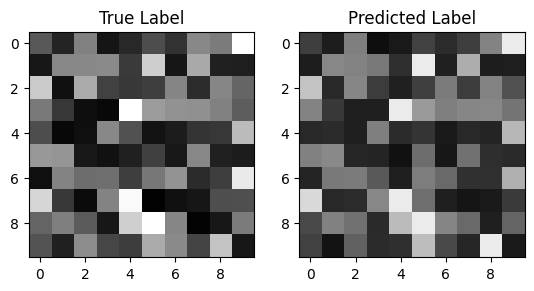

In [10]:
# 对测试集进行预测
a = datetime.now()
print(f'开始测试时间：{a}')
y_pred_flat = knn.predict(test_samples)
b = datetime.now()
print(f'结束测试时间：{b}')
print(f'测试用时：{b-a}')
print()

# 计算均方误差
mse = mean_squared_error(test_depths, y_pred_flat)
print(f"Mean Squared Error: {mse:.6f}")

# 可以将预测结果恢复为原始的图像尺寸（1, 10, 10）
y_pred = y_pred_flat.reshape(10, 10)
y_test_reshaped = test_depths.reshape(10, 10)

# 显示一部分预测结果与真实标签
plt.subplot(1, 2, 1)
plt.imshow(y_test_reshaped, cmap='gray', vmin=0, vmax=1)
plt.title("True Label")

plt.subplot(1, 2, 2)
plt.imshow(y_pred, cmap='gray', vmin=0, vmax=1)
plt.title("Predicted Label")

plt.show()


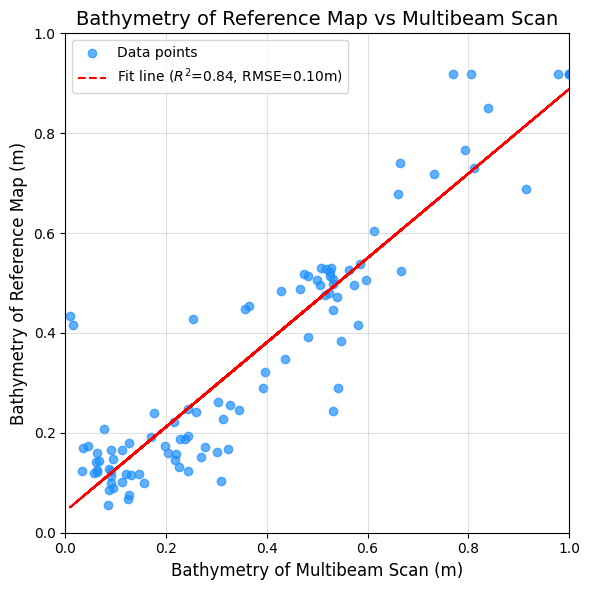

In [11]:
# 计算回归直线
y_true_ = test_depths.flatten()
y_pred_ = y_pred_flat.flatten()
coefficients = np.polyfit(y_true_, y_pred_, 1)  # 一次线性拟合
poly_eq = np.poly1d(coefficients)
y_fit = poly_eq(y_true_)

# 计算 R^2 和 RMSE
r_squared = r2_score(y_pred_, y_fit)
rmse = np.sqrt(mean_squared_error(y_pred_, y_fit))

# 绘图
plt.figure(figsize=(6, 6))
plt.scatter(y_true_, y_pred_, color='dodgerblue', alpha=0.7, label='Data points')  # 数据点
plt.plot(y_true_, y_fit, color='red', linestyle='--', label=f'Fit line ($R^2$={r_squared:.2f}, RMSE={rmse:.2f}m)')  # 拟合直线

# 图表修饰
plt.title('Bathymetry of Reference Map vs Multibeam Scan', fontsize=14)
plt.xlabel('Bathymetry of Multibeam Scan (m)', fontsize=12)
plt.ylabel('Bathymetry of Reference Map (m)', fontsize=12)
plt.legend()
plt.grid(alpha=0.4)
# plt.xlim(-25, 0)
# plt.ylim(-25, 0)
plt.xlim(0, 1)
plt.ylim(0, 1)

# 显示图表
plt.tight_layout()
plt.show()

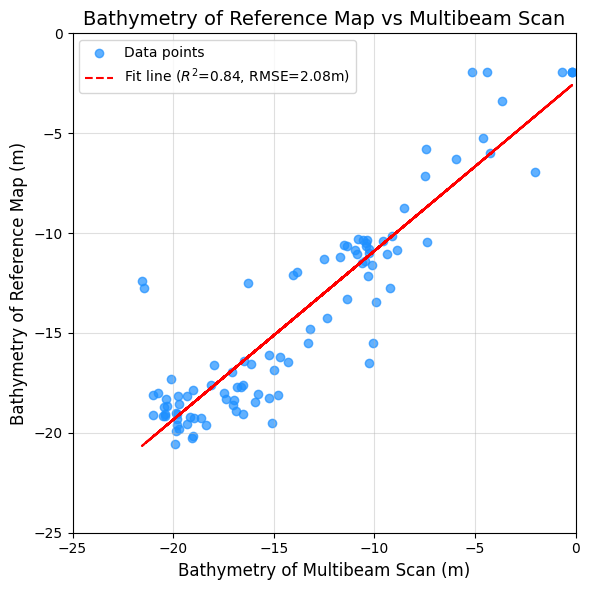

In [12]:
# denormalize
y_true = y_true_ * (depthmax - depthmin) + depthmin
y_pred = y_pred_ * (depthmax - depthmin) + depthmin

# 计算回归直线
coefficients = np.polyfit(y_true, y_pred, 1)  # 一次线性拟合
poly_eq = np.poly1d(coefficients)
y_fit = poly_eq(y_true)

# 计算 R^2 和 RMSE
r_squared = r2_score(y_pred, y_fit)
rmse = np.sqrt(mean_squared_error(y_pred, y_fit))

# 绘图
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, color='dodgerblue', alpha=0.7, label='Data points')  # 数据点
plt.plot(y_true, y_fit, color='red', linestyle='--', label=f'Fit line ($R^2$={r_squared:.2f}, RMSE={rmse:.2f}m)')  # 拟合直线

# 图表修饰
plt.title('Bathymetry of Reference Map vs Multibeam Scan', fontsize=14)
plt.xlabel('Bathymetry of Multibeam Scan (m)', fontsize=12)
plt.ylabel('Bathymetry of Reference Map (m)', fontsize=12)
plt.legend()
plt.grid(alpha=0.4)
plt.xlim(-25, 0)
plt.ylim(-25, 0)

# 显示图表
plt.tight_layout()
plt.show()